### Choisir et importer un algorithme de ML (Algorithme de Machine Learning)

In [66]:
# Les Bibliothèques
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import joblib



In [2]:
# importons notre df_features
df_features = pd.read_csv("../data/processed/df_features.csv")

display(df_features.head())



,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,senior,high_glucose,cardio_risk
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,1,1,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1,0,1,0
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,1,0,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,0,1,0
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,1,1,1


##### Nous allons faire une rapide vérification sécuritaire

In [3]:
print(df_features.shape)

(5109, 14)


In [4]:
print(df_features.info())

<class 'pandas.DataFrame'>
RangeIndex: 5109 entries, 0 to 5108
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5109 non-null   str    
 1   age                5109 non-null   float64
 2   hypertension       5109 non-null   int64  
 3   heart_disease      5109 non-null   int64  
 4   ever_married       5109 non-null   str    
 5   work_type          5109 non-null   str    
 6   Residence_type     5109 non-null   str    
 7   avg_glucose_level  5109 non-null   float64
 8   bmi                5109 non-null   float64
 9   smoking_status     5109 non-null   str    
 10  stroke             5109 non-null   int64  
 11  senior             5109 non-null   int64  
 12  high_glucose       5109 non-null   int64  
 13  cardio_risk        5109 non-null   int64  
dtypes: float64(3), int64(6), str(5)
memory usage: 558.9 KB
None


In [5]:
print(df_features.isna().sum())

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
senior               0
high_glucose         0
cardio_risk          0
dtype: int64


In [6]:
print(df_features.duplicated().sum())

0


##### Nous alors refaire le preprocessing avec ce dataset de manière plus fluide

In [ ]:
# définissons nos variablesexplicatives

X = df_features.drop(columns = "stroke")
# notre variable cible
y = df_features["stroke"]


In [8]:
# vérifions
X.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,senior,high_glucose,cardio_risk
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,1,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,0,1,0
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,0,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,0,1,0
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,1,1


In [9]:
y.info()

<class 'pandas.Series'>
RangeIndex: 5109 entries, 0 to 5108
Series name: stroke
Non-Null Count  Dtype
--------------  -----
5109 non-null   int64
dtypes: int64(1)
memory usage: 40.0 KB


In [10]:
# identifions les variables
cat_features = X.select_dtypes(include = str).columns

num_features = X.select_dtypes(exclude = str).columns


In [11]:
# Vérifions
print("cat_features contient: " , cat_features)

print()

print("num_features contient: " , num_features)

cat_features contient:  Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='str')

num_features contient:  Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
       'senior', 'high_glucose', 'cardio_risk'],
      dtype='str')


In [12]:
# Séparons nos variables par le Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
                                    X,
                                    y,
                                    random_state=42,
                                    test_size= 0.20,
                                    stratify=y

                                        )


In [13]:
print("X_train: ", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train: ", y_train.shape)
print("y_test: ", y_test.shape)


X_train:  (4087, 13)
X_test:  (1022, 13)
y_train:  (4087,)
y_test:  (1022,)


In [14]:
# Vérification des valeurs manquantes comme nous l'avons fait ci-dessus
print(df_features.isna().sum())

# Aucune valeur manquante.
# L'imputation a déjà été réalisée lors de la création du dataset clean.

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
senior               0
high_glucose         0
cardio_risk          0
dtype: int64


#### Préparation finale des données avant l'entraînement des modèles

###### Encodage des variables catégorielles

In [15]:
# nos variables catégorielles
print(cat_features)

Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='str')


In [16]:
# modèle encodeur
encoder = OneHotEncoder(drop= 'first',
                        handle_unknown='ignore',
                        sparse_output= False)


In [17]:
# Apprend et transforme nos variables train catégorielles
X_train_encoded_array = encoder.fit_transform(X_train[cat_features])

# Transforme nos variables test catégorielles 
X_test_encoded_array = encoder.transform(X_test[cat_features])

# Récupérons les noms des colonnes 
encoded_columns = encoder.get_feature_names_out(cat_features)


In [18]:
# Construisons les Dataframes
# Dataframe Train
X_train_encoded = pd.DataFrame(
                            X_train_encoded_array,
                            columns= encoded_columns,
                            index= X_train.index
                            )

X_train_encoded.head()


,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
845,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3744,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4183,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3409,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
284,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [19]:
# Dataframe Test
X_test_encoded = pd.DataFrame(
                            X_test_encoded_array,
                            columns= encoded_columns,
                            index= X_test.index
                                )

X_test_encoded.head()


,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
3666,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2217,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
374,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2392,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
299,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
print("X_train_encoded:" , X_train_encoded.shape)
print("X_test_encoded: ", X_test_encoded.shape)

X_train_encoded: (4087, 10)
X_test_encoded:  (1022, 10)


In [21]:
# vérifions qu'il y'a pas de nan après encodage
X_train_encoded.isna().sum()

gender_Male                       0
ever_married_Yes                  0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
Residence_type_Urban              0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
dtype: int64

In [22]:
X_test_encoded.isna().sum()

gender_Male                       0
ever_married_Yes                  0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
Residence_type_Urban              0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
dtype: int64

##### Standardisation des variables numériques

In [23]:
# Variables numériques
print(num_features)

Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
       'senior', 'high_glucose', 'cardio_risk'],
      dtype='str')


In [24]:
# Nous observons que parmis nos variables numériques, certaines sont déjà numériques et binaires donc n'ont 
# plus besoin d'être standardiser.
# Afin que l'ensemble de nos variable snumériques soient sur la même échelle, nous allons standardiser les variables qui en ont besoin
# telles que: age, avg_glucose_level et bmi

X_train[num_features].head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,senior,high_glucose,cardio_risk
845,48.0,0,0,69.21,33.1,0,0,0
3744,29.0,0,0,84.19,21.2,0,0,0
4183,35.0,0,0,119.40,22.9,0,0,0
3409,38.0,0,0,108.68,32.7,0,0,0
284,14.0,0,0,82.34,31.6,0,0,0


In [25]:
# Nous allons classer nos variables numériques continues
continuous_features = [
    "age",
    "avg_glucose_level",
    "bmi"
]

# Classons nos variables numériques binaires
binary_features = [
    "hypertension",
    "heart_disease",
    "senior",
    "high_glucose",
    "cardio_risk"
]


In [26]:
# modèle scaler
scaler = StandardScaler()


In [27]:
# Stantardissons uniquement nos variables numériques continues
# Jeu d'entrainement
X_train[continuous_features] = scaler.fit_transform(X_train[continuous_features])

# Jeu de test
X_test[continuous_features] = scaler.transform(X_test[continuous_features])


In [28]:
# Vérification
X_train[continuous_features].describe().round(2)

,age,avg_glucose_level,bmi
count,4087.00,4087.00,4087.00
mean,-0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-1.91,-1.13,-2.40
25%,-0.81,-0.64,-0.66
50%,0.08,-0.31,-0.10
75%,0.78,0.18,0.51
max,1.71,3.71,8.89


##### Concaténation de nos différentes variables:
- variables catégorielles encodées,
- variables numériques standardisées,
- variables binaires.

In [29]:
# reconstituons notre X_train_numeric
X_train_numeric = X_train[continuous_features + binary_features]

# reconstituons notre X_test_numeric
X_test_numeric = X_test[continuous_features + binary_features]


In [30]:
# Concaténation X_train_final
X_train_final = pd.concat( 
    [X_train_encoded,
     X_train_numeric
    ],
    axis=1
)

# Vérification
X_train_final.head()

,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,age,avg_glucose_level,bmi,hypertension,heart_disease,senior,high_glucose,cardio_risk
845,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.209397,-0.821221,0.549234,0,0,0,0,0
3744,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,-0.629845,-0.485884,-0.988900,0,0,0,0,0
4183,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.364822,0.302317,-0.769166,0,0,0,0,0
3409,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.232310,0.062342,0.497532,0,0,0,0,0
284,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-1.292405,-0.527297,0.355351,0,0,0,0,0


In [31]:
# Concaténation X_test_final
X_test_final = pd.concat(
    [
        X_test_encoded,
        X_test_numeric
    ],
    axis=1
)

# Vérification

X_test_final.head()

,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,age,avg_glucose_level,bmi,hypertension,heart_disease,senior,high_glucose,cardio_risk
3666,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.674016,-0.497748,0.975775,1,0,0,0,1
2217,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,-1.778282,-0.281950,-1.208633,0,0,0,0,0
374,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.430250,-0.928896,0.277798,0,0,0,0,0
2392,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.364822,-0.820997,1.803007,0,0,0,0,0
299,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.651103,-0.259564,0.032214,0,0,0,0,0


In [32]:
print("X_train_final: ", X_train_final.shape)
print("X_test_final: ", X_test_final.shape)

X_train_final:  (4087, 18)
X_test_final:  (1022, 18)


##### Appliquons SMOTE
SMOTE nous permettra comme nous l'avons vu dans le fichier 02, qu'il fabrique de nouveaux patients uniquement dans la classe minoritaire.Puisque notre cible stroke est déséquilibré.

In [33]:
# modèle
smote = SMOTE(random_state=42)

# sur notre jeu d'entrainement

X_train_balanced, y_train_balanced = smote.fit_resample( X_train_final, y_train)


In [34]:
print("X_train_balanced: ", X_train_balanced.shape)
print("y_train_balanced: ", y_train_balanced.shape)

X_train_balanced:  (7776, 18)
y_train_balanced:  (7776,)


In [ ]:
# Importons nos échantillons balanced pour une réutilisation

X_train_balanced.to_csv("../data/processed/X_train_balanced.csv")

y_train_balanced.to_csv("../data/processed/y_train_balanced.csv")

#### Machine Learning

##### Régression Logistique

In [35]:
# Créer le modèle 
log_model = LogisticRegression(
                                random_state= 42, 
                                max_iter=1000
                                )


In [36]:
# Entrainement de notre modèle
log_model.fit(X_train_balanced, y_train_balanced)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

Nous allons évaluer le modèle sur des données qu'il n'a jamais vues donc notre X_test_final.
Ce qui nous permettra de mesurer sa capacité à généraliser.

In [37]:
# Prédiction par notre modèle
y_pred = log_model.predict(X_test_final)


#### Evaluons notre modèle

In [38]:
# Accuracy: qui nous dira a quel pourcentage notre modèle prédit bien

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy: .3f}")

Accuracy:  0.714


Le modèle prédit bien 71.4% des patients

In [39]:
# Classification report qui nous donnera: Precision, Recall et f1-scrore

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.71      0.83       972
           1       0.13      0.82      0.22        50

    accuracy                           0.71      1022
   macro avg       0.56      0.76      0.52      1022
weighted avg       0.95      0.71      0.80      1022



Analysons notre Classification_report:

- Precision: pour la classe AVC 13% seulement des vrais AVC et 87% seraient des faux positifs.

- Recall: pour la classe AVC on a 82% des vrais AVC donc sur 100 patients qui ont un AVC, le modèle prédira correctement 82. 
Le recall nous permettant de moins prédire les Faux Négatif; ce qui serait grave médicalement.

- f1-score: pour la classe AVC on a 22% ce qui est faible. A cause d'une excellente capacité à retrouver les malades (Recall), mais une faible précision.

Pour la classe SANS AVC :

on a une Precision: 99% et un Recall: 71% 
Le modèle reconnaît très bien les personnes en bonne santé lorsqu'il les classe comme telles, mais il en requalifie beaucoup en "AVC" par prudence.


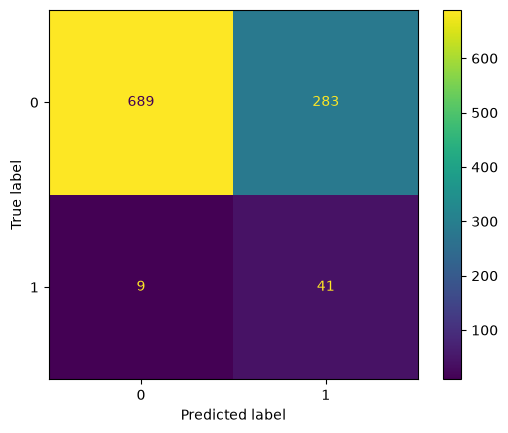

In [40]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix = cm).plot()

En analysant notre matrice de confusion, nous pouvons dire que:
- Parmis les 50 patients ayant réellement l'AVC, le modèle prédict correctement 41 on parle de True Positif (TP) et il oubli 9 on parle de Faux Négatif (FN)

- Parmis les 972 patients n'ayant pas eu d'AVC, le modèle prédict correctement 689 on parle de True Negatif (TN) et il oubli 283 on parle de Faux Positif (FP).

On constate que le modèle préfère dire "AVC" plutôt que risquer d'oublier un patient.
Ce qui n'est pas mauvais car le modèle:
- retrouve beaucoup de patients malades, 
- ne manque que 9 AVC,
- mais il envoie beaucoup de patients sains faire des examens inutiles.


De manière générale, on dira que:

La Régression Logistique obtient une accuracy de 71 %, mais à cause du déséquilibre des données elle est peu pertinente. 
Le point positif est un recall de 82 % sur la classe AVC, ce qui signifie que le modèle détecte la majorité des patients à risque. En revanche, la précision de seulement 13 % révèle un nombre important de faux positifs. 

Pour un contexte médical, ce compromis peut être acceptable dans une première approche, car il est souvent préférable de réaliser des examens complémentaires chez des patients sains plutôt que de manquer un véritable AVC. 

Nous allons donc tester d'autres modèles plus performant comme Decision tree, Random Forest ou XGBoost, afin d'améliorer la précision sans dégrader le rappel.

##### Decision Tree

In [41]:
# modèle
tree_model = DecisionTreeClassifier(random_state=42)

In [42]:
# Entrainons notre modèle
tree_model.fit(X_train_balanced, y_train_balanced)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [43]:
# Prédiction de notre modèle
y_pred_tree = tree_model.predict(X_test_final)

##### Evaluons notre Decision Tree

In [44]:
# Accuracy
accuracy_tree = accuracy_score(y_test, y_pred_tree)

print(f"Accuracy: {accuracy_tree: .3f}")

Accuracy:  0.887


Ici, notre modèle prédit bien 88.7% de nos données.

In [45]:
# Classification_report
print(classification_report(y_test, y_pred_tree))


              precision    recall  f1-score   support

           0       0.96      0.92      0.94       972
           1       0.14      0.26      0.18        50

    accuracy                           0.89      1022
   macro avg       0.55      0.59      0.56      1022
weighted avg       0.92      0.89      0.90      1022



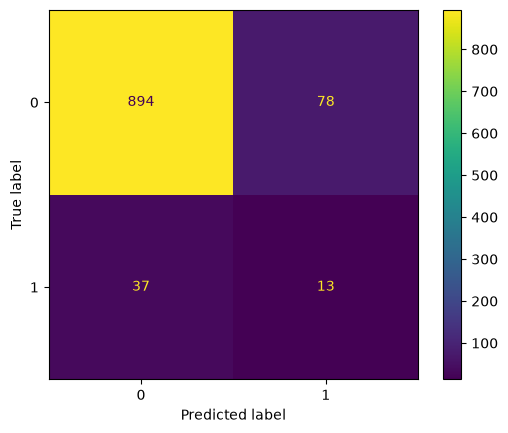

In [46]:
# Matrix de confusion

cm_tree = confusion_matrix(y_test,y_pred_tree)

# Affichons

ConfusionMatrixDisplay(confusion_matrix= cm_tree).plot()


La matrice nous montre que sur les 50 patients qui ont rééllement l'AVC, le modèle prédit correctement 13 patients et il oublie 37 patients. Ce qui est conséquent malgré son fort pourcentage de prédiction (88.7%).
En comparaison avec le modèle de Regression Logistique, le Decision Tree oublie plus de quatre fois plus de patients malades (avec un recall de 26% contre 82% avec la regression logistique).

Ce qui est problématique dans un contexte médical.

le Decision tree est un modèle moins adapté pour cette problématique dans sa version actuelle.

##### Random Forest

In [47]:
# Modèle
rf_model = RandomForestClassifier(n_estimators=100, 
                                      random_state=42
                                      )


In [48]:
# Entrainer le modèle
rf_model.fit(X_train_balanced, y_train_balanced)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [49]:
# Prediction du modèle

y_pred_rf = rf_model.predict(X_test_final)

###### Evaluation du modèle Random Forest

In [50]:
# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy: {accuracy_rf: .3f}")


Accuracy:  0.923


In [51]:
# report
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.95      0.97      0.96       972
           1       0.13      0.10      0.11        50

    accuracy                           0.92      1022
   macro avg       0.54      0.53      0.54      1022
weighted avg       0.91      0.92      0.92      1022



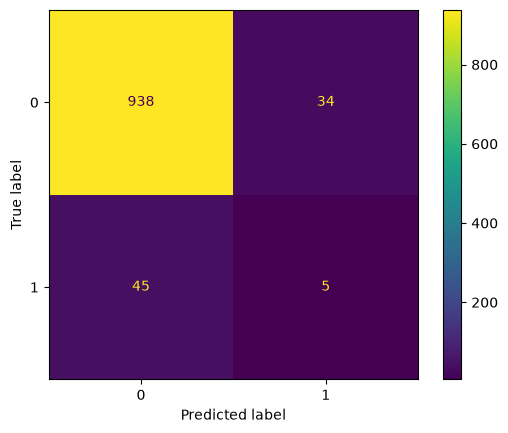

In [52]:
# Matrix de Confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Affichons
ConfusionMatrixDisplay(confusion_matrix= cm_rf).plot()


Malgré un Accuracy_score élévé, notre report et la matrice nous renvoient que le modèle n'est pas adapté à notre problématique.

Nous observons que sur 50 patients réellement victimes d'un AVC, la Random Forest en détecte seulement 5
patients et elle en oublie 45 patients. Ce qui est énorme pour notre évaluation.

Le recall qui est de 10% pour les patients ayant fait un AVC, 90 % des patients réellement victimes d'un AVC ne sont pas détectés. Pour un modèle médical ce serait inacceptable.


Bien que la Random Forest reste le modèle détectant le moins de faux positif (34), elle laisse repartir beaucoup trop de patients réellement malades. Ce qui est plus dangereux.

Nous observons que le déséquilibre de notre variable cible impacte sur notre modèle tel le Decision Tree; la regression logistique reste jusqu'à lors le modèle qui donne moins de faux négatifs(9).

Les paramètres par défaut de la Random Forest ne sont pas adaptés à notre problématique, ce qui justifie une future phase d'optimisation des hyperparamètres.


##### XGBoost : eXtreme Gradient Boosting


In [59]:
# Créer le modèle
xgb_model = XGBClassifier(random_state = 42, eval_metric = "logloss")


In [60]:
# Entrainer le modèle
xgb_model.fit(X_train_balanced, y_train_balanced)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [65]:
# Prédiction
y_pred_xgb = xgb_model.predict(X_test_final)



##### Evaluation du modèle XGB

In [62]:
# Accuracy
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"Accuracy de XGB: {accuracy_xgb: .3f}")


Accuracy de XGB:  0.932


Ce model prédit bien 93.2% de nos patients.

In [63]:
# Report

print(classification_report(
                                y_test,
                                y_pred_xgb
                                ))


              precision    recall  f1-score   support

           0       0.96      0.97      0.96       972
           1       0.21      0.14      0.17        50

    accuracy                           0.93      1022
   macro avg       0.58      0.56      0.57      1022
weighted avg       0.92      0.93      0.93      1022



Concernant la precision: lorsque XGBoost prédit qu'un patient est à risque d'AVC, il a raison dans 21 % des cas.

Concernant le recall: parmi tous les patients ayant réellement subi un AVC, le modèle n'en détecte que 14 %.


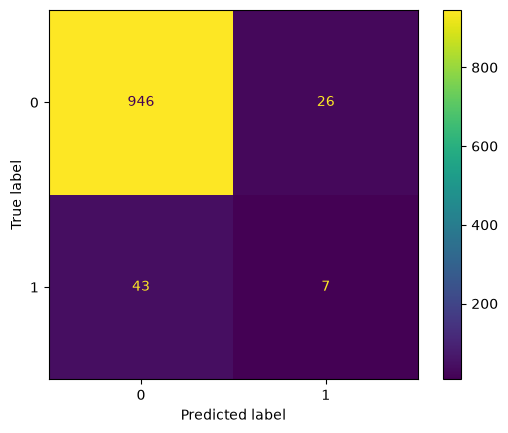

In [64]:
# Matrix de confusion

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Afficher

ConfusionMatrixDisplay(confusion_matrix= cm_xgb).plot()


Le modèle a annoncé 33 patients AVC, parmi eux seulement 7 avaient réellement un AVC.
Donc : 7 / 33 environ 21 %.

Il y avait 50 vrais AVC et le modèle en retrouve juste 7

Donc : 7 / 50 environ 14 %.

Cela signifie que le modèle XGB laisse passer 43 patients. Dans le contexte médiacle, c'est énorme.


#### Point sur nos moèles utilisés basiquement

Au début de ce training, je pensais qu'en multipliant les modèles de par leur complexité, j'aurais de meilleurs résultats pour détecter les patients ayant subit un AVC.

Il en ressort de manière générale que la Régression Logistique, étant le modèle le plus simple, reste celui qui détecte le mieux les patients à risque.


Notre objectif n'est pas d'obtenir la meilleure Accuracy.

Notre objectif est de détecter un maximum de patients susceptibles de faire un AVC.

Dans ce contexte :

Le Recall est beaucoup plus important. Ce qu'offre le modèle de Regression Logistique jusqu'ici.
Alors que les autre smodèles préfèrent dire: PAS AVC par prudence. Alors que ce n'est pas ce que nous voulons cela est médicalement risqué un Faux Négatif.

Nous allons améliorer nos modèles en optimisant les hyperparamètres de certains de nos modèles pour de meilleurs résultats pour répondre à notre objectif.


### Sauvegarde des modèles

In [ ]:
# Regression Logistique

joblib.dump(log_model, "../models/logistic_regression.pkl")


['../models/logistic_regression.pkl']

In [72]:
#Decision Tree

joblib.dump(tree_model, "../models/decision_tree.pkl")

['../models/decision_tree.pkl']

In [73]:
# Random Forest

joblib.dump(rf_model, "../models/random_forest.pkl")


['../models/random_forest.pkl']

In [74]:
# XGBoost 

joblib.dump(xgb_model, "../models/xgboost.pkl")

['../models/xgboost.pkl']

### Sauvegarde de l'encoder et du scaler

In [75]:
# OneHotEncoder

joblib.dump(encoder, "../models/one_hot_encoder.pkl")

# Standard Scaler

joblib.dump(scaler, "../models/standard_scaler.pkl")

['../models/standard_scaler.pkl']

Ainsi nous pourrons réutiliser nos modèles si nécessaires.